Opening raw data file C:\Users\Hangeulkim\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 3965 samples (6.602 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design

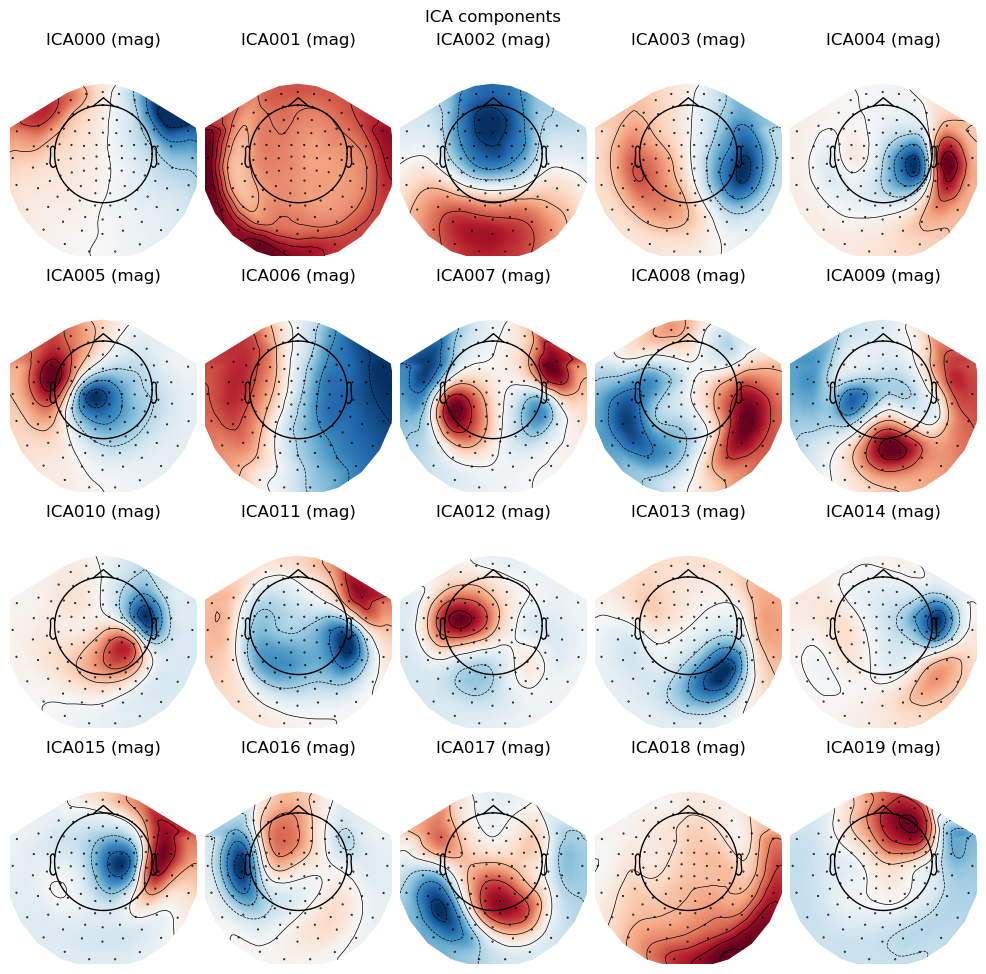

Using EOG channel: EOG 061
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 6007 samples (10.001 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz

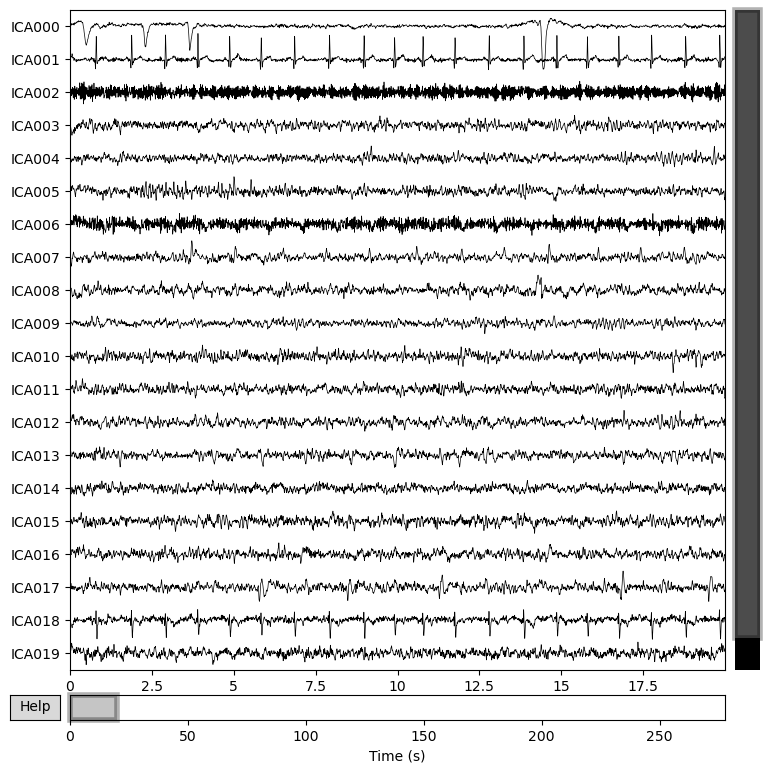

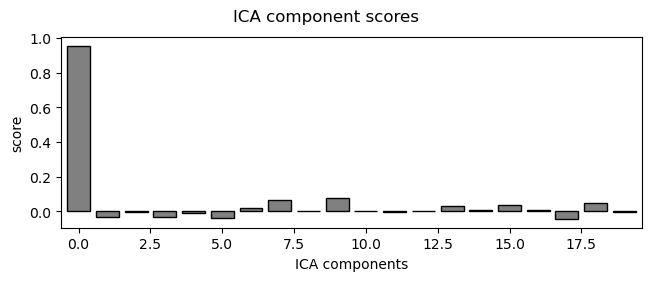

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated


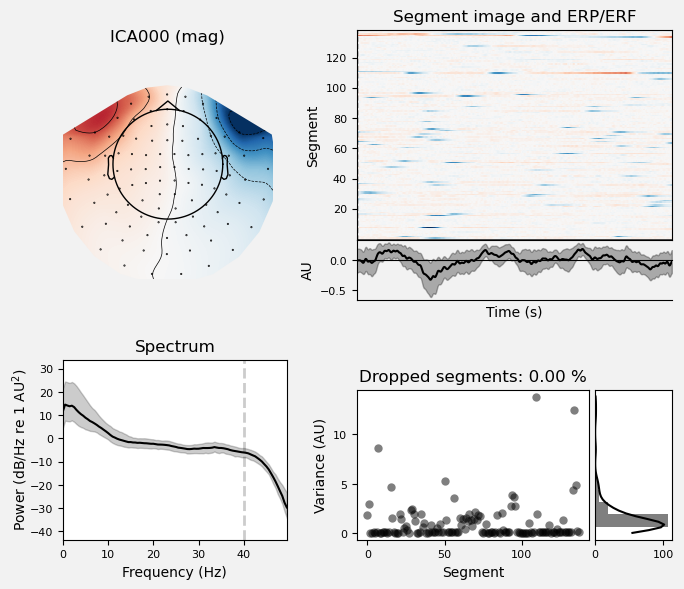

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 1 ICA component
    Projecting back using 364 PCA components


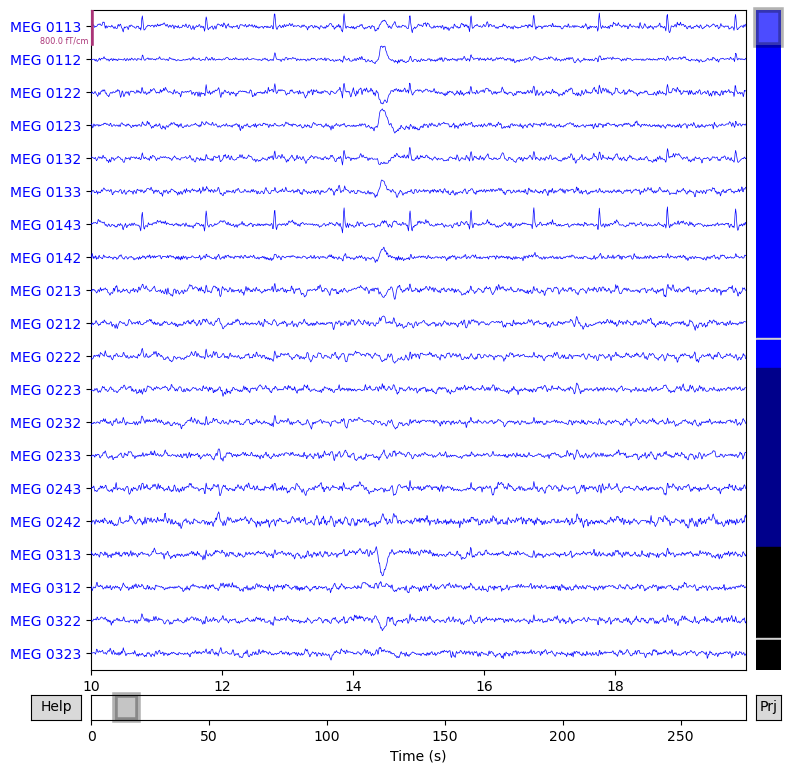

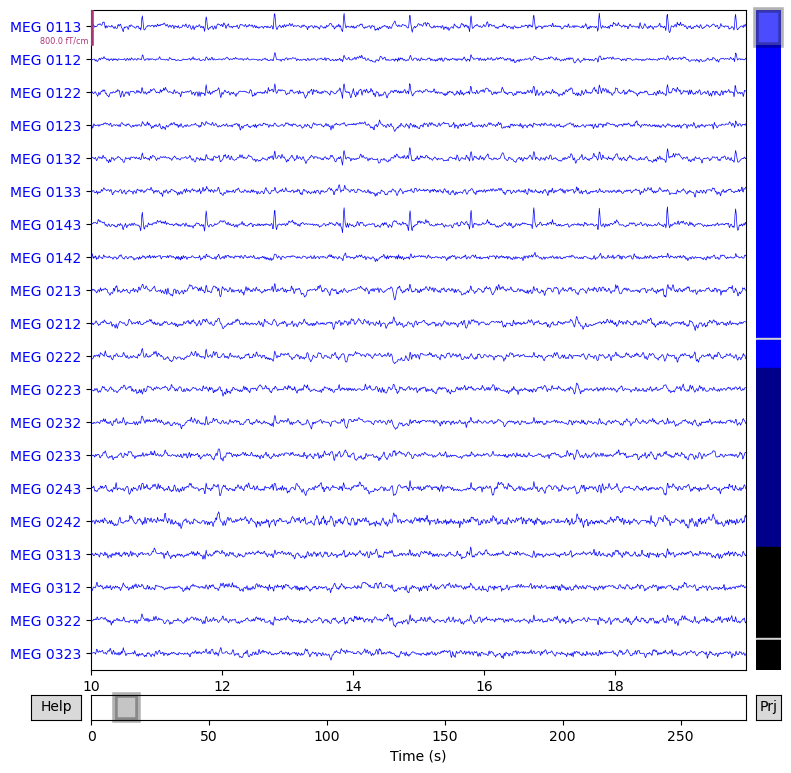

Creating RawArray with float64 data, n_channels=21, n_times=166800
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


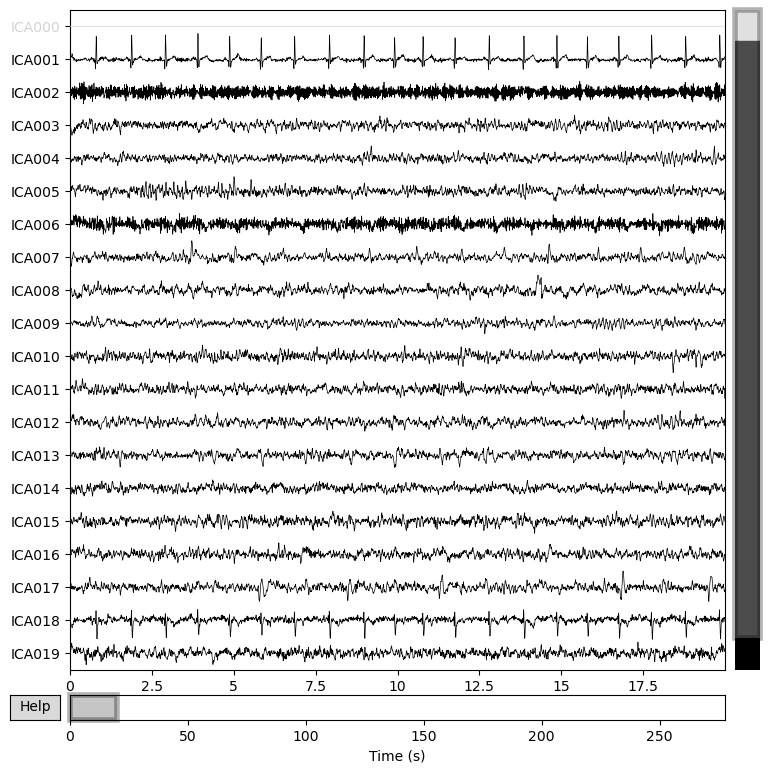

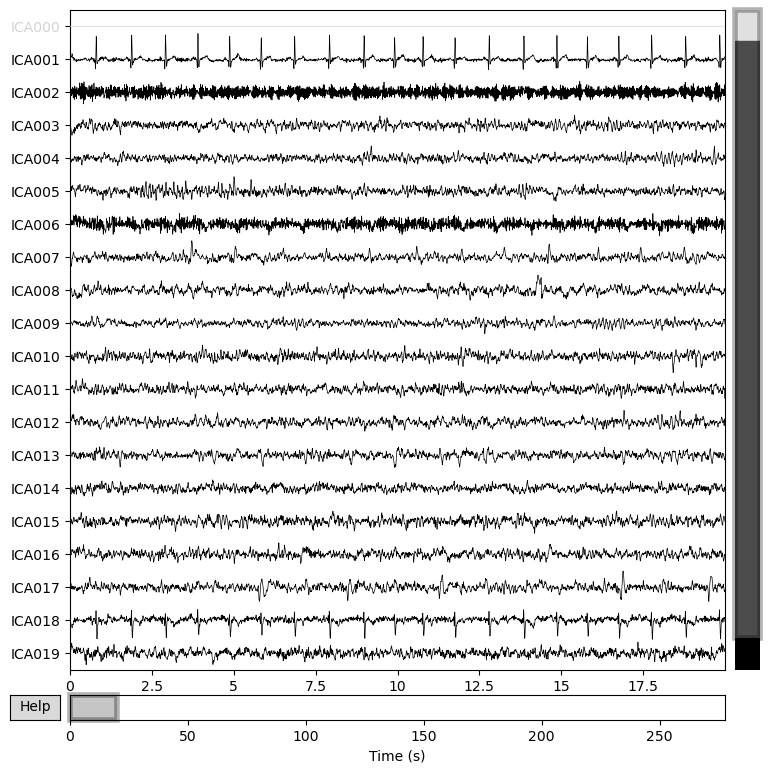

In [1]:
import mne
import numpy as np

sample = mne.datasets.sample.data_path()
raw = mne.io.read_raw_fif(sample/'MEG'/'sample'/'sample_audvis_raw.fif', preload=True)

# TODO: 60Hz notch + 1~40Hz bandpass
raw.notch_filter(freqs=np.arange(60,raw.info['sfreq']/2-5,60)).filter(1., 40.)

ica = mne.preprocessing.ICA(n_components=20, random_state=42)
ica.fit(raw)
ica.plot_components()

eog_indices, eog_scores = ica.find_bads_eog(raw)
print("EOG components:", eog_indices)

ica.plot_sources(raw, show_scrollbars=True)   # 시간축 — 큰 스파이크 IC 찾기
ica.plot_scores(eog_scores)                    # 점수 막대그래프
ica.plot_properties(raw, picks=eog_indices)    # 4분할 종합

# TODO: ica.exclude에 넣고 raw_clean = ica.apply(raw.copy())
ica.exclude = eog_indices
raw_clean = ica.apply(raw.copy())

raw.plot(duration=10, start=10, title='Before ICA')
raw_clean.plot(duration=10, start=10, title='After ICA')

ica.plot_sources(raw_clean, title='After: IC0 should be ~0')

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 1 ICA component
    Projecting back using 364 PCA components


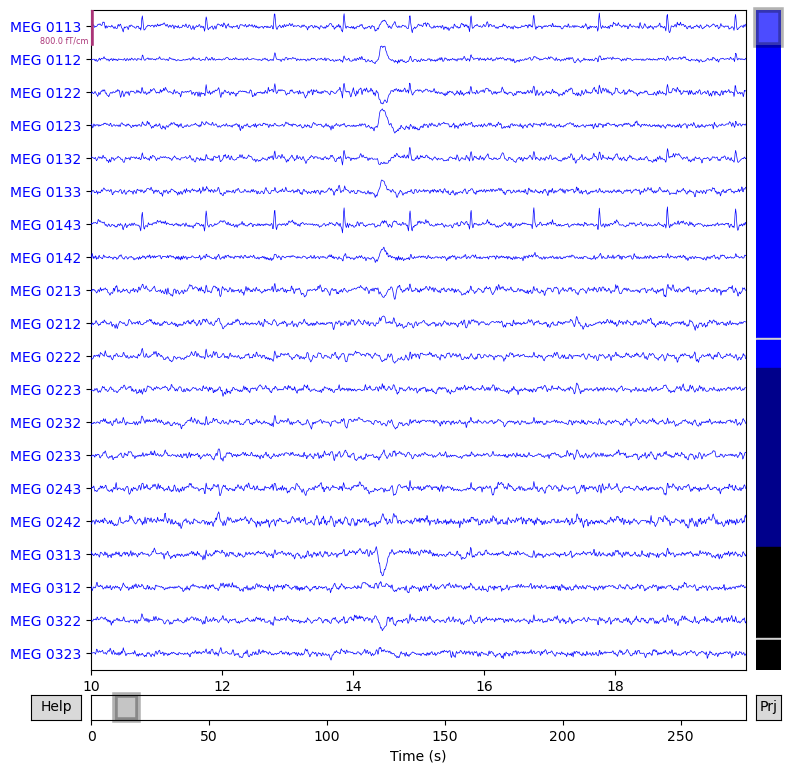

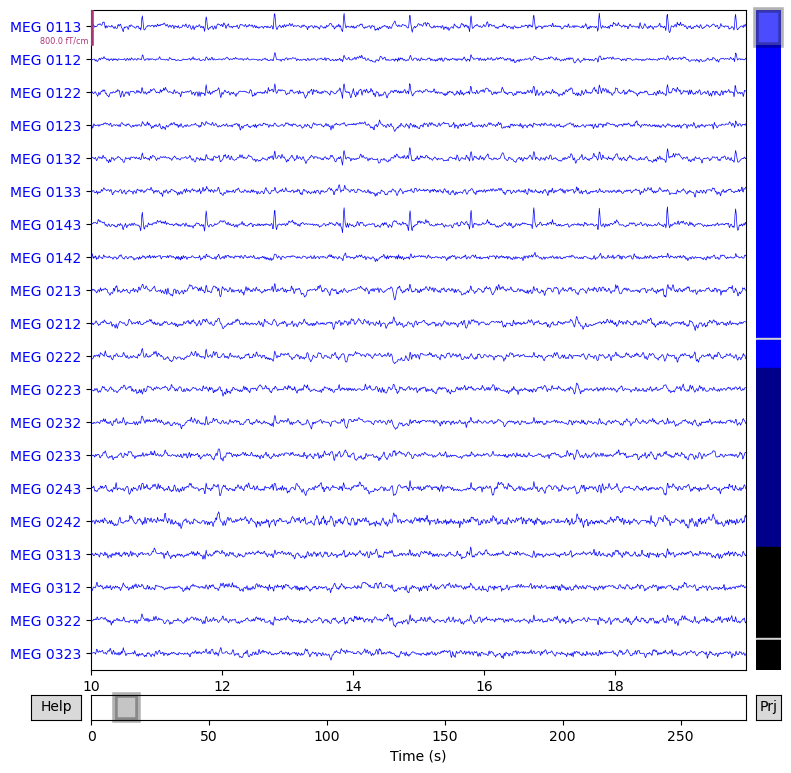

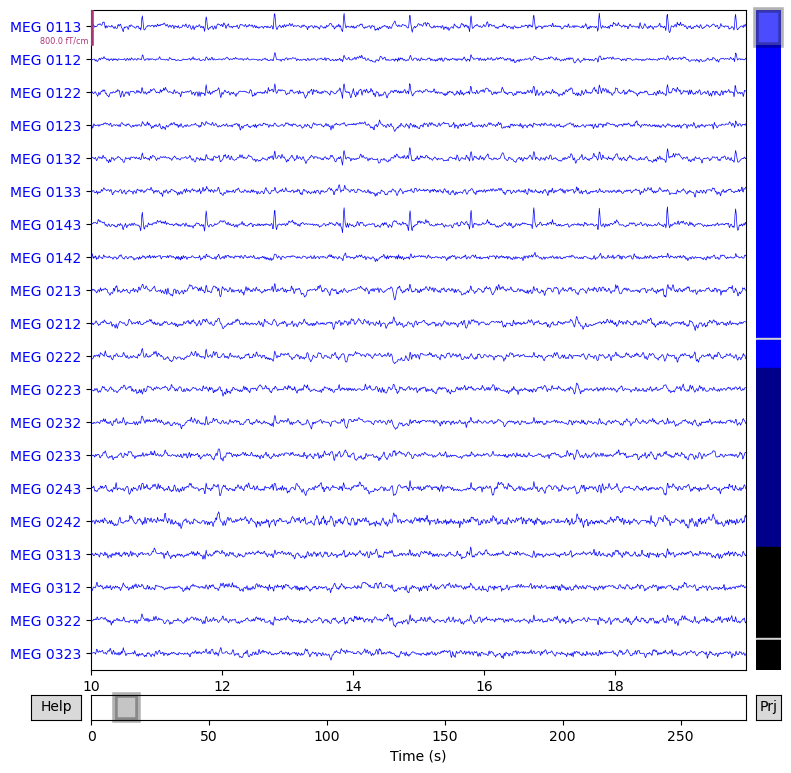

Fitting ICA to data using 364 channels (please be patient, this may take a while)
Selecting by number: 10 components
Fitting ICA took 2.8s.


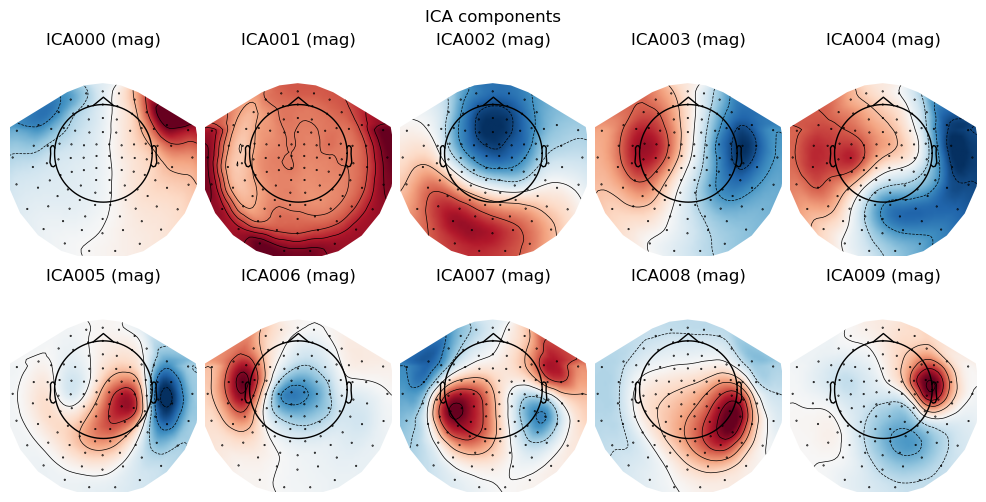

Fitting ICA to data using 364 channels (please be patient, this may take a while)
Selecting by number: 30 components
Fitting ICA took 7.2s.


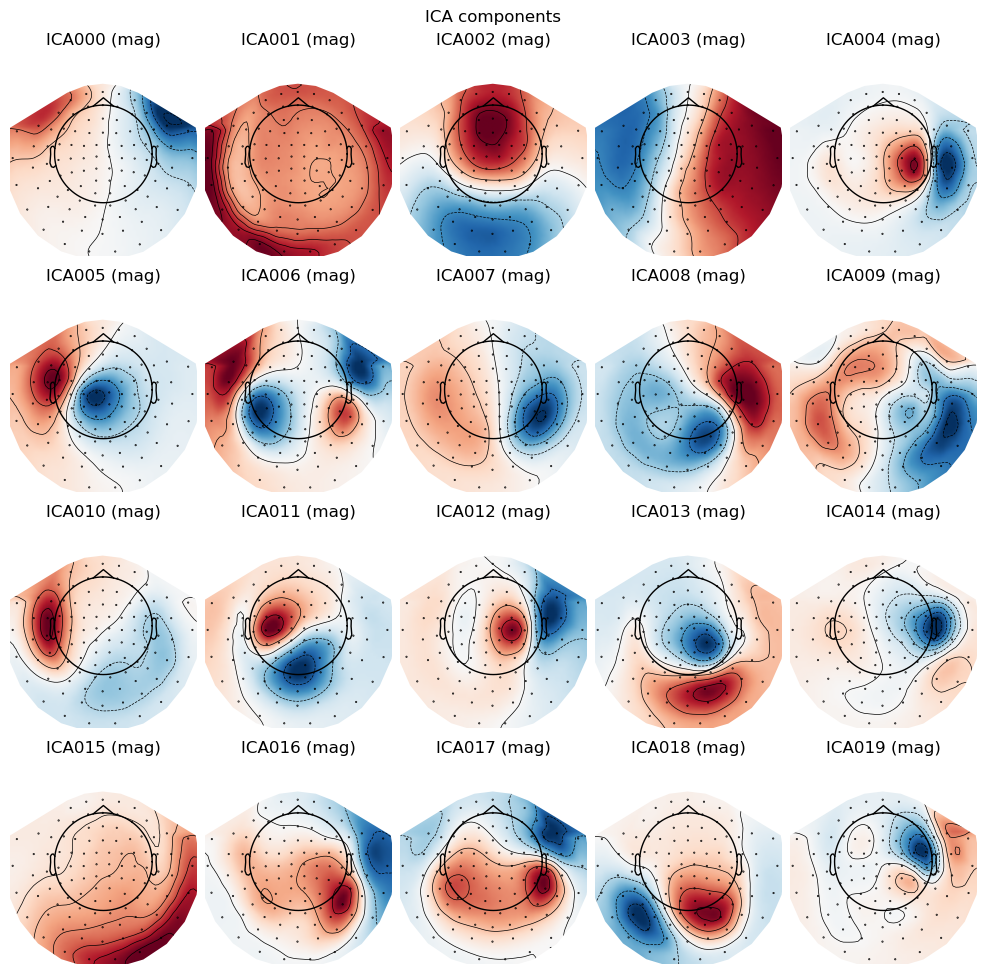

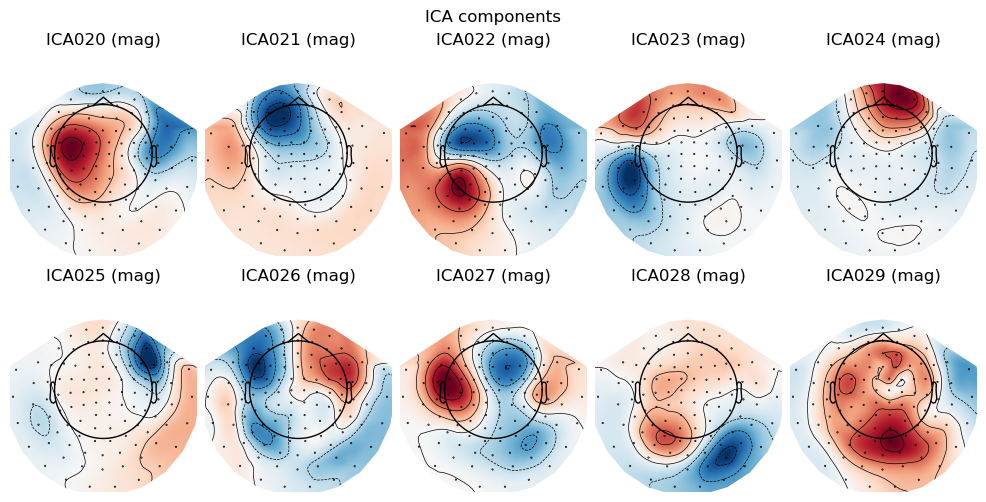

Using EOG channel: EOG 061
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 6007 samples (10.001 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz

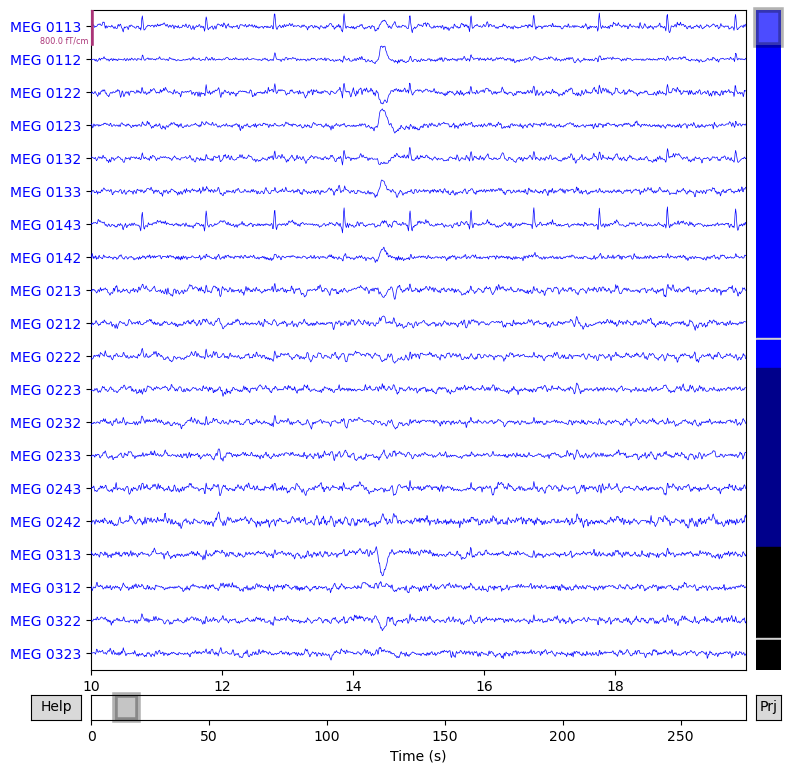

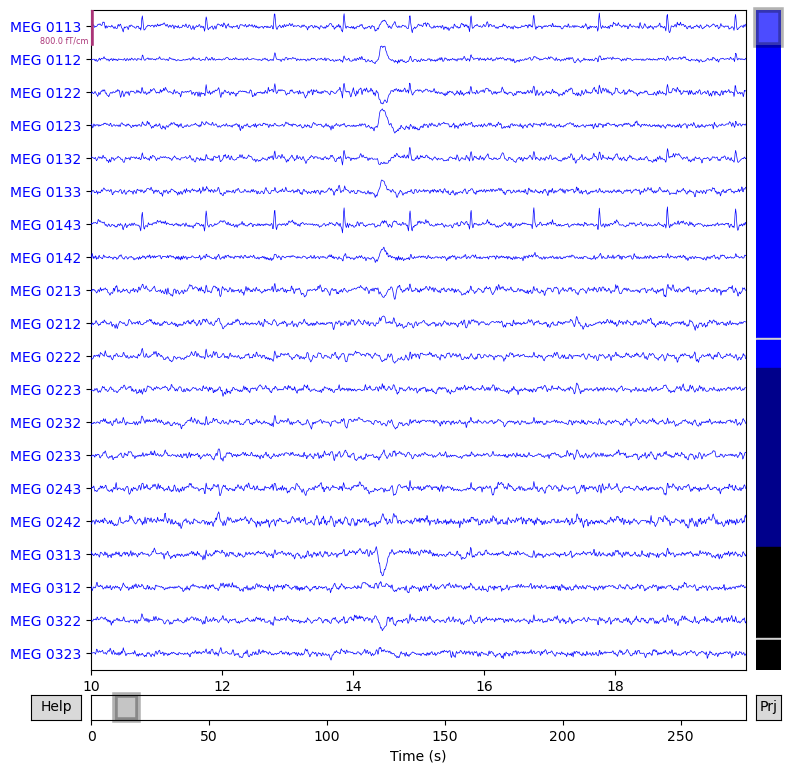

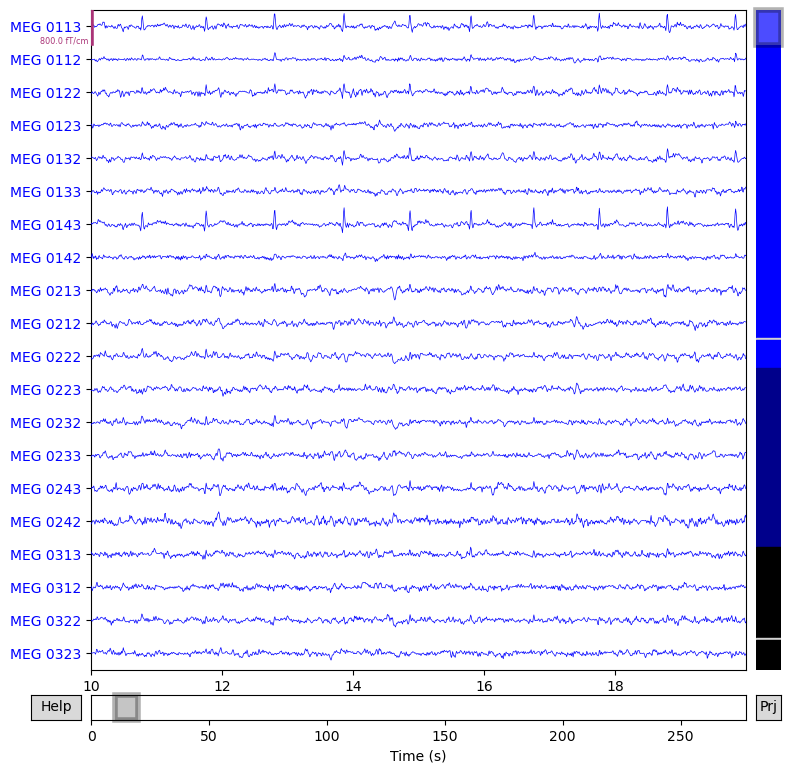

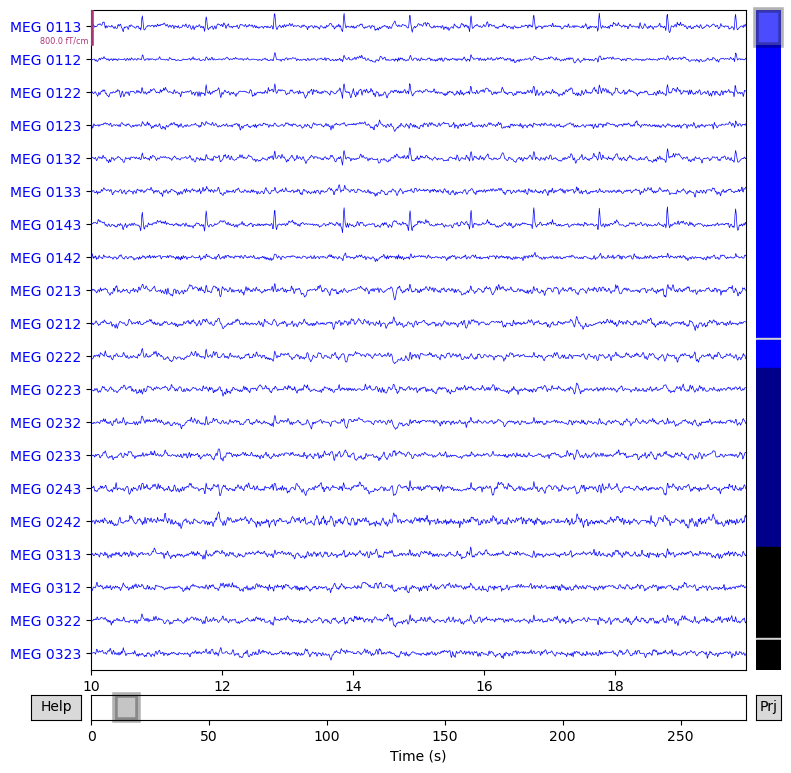

Creating RawArray with float64 data, n_channels=21, n_times=166800
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


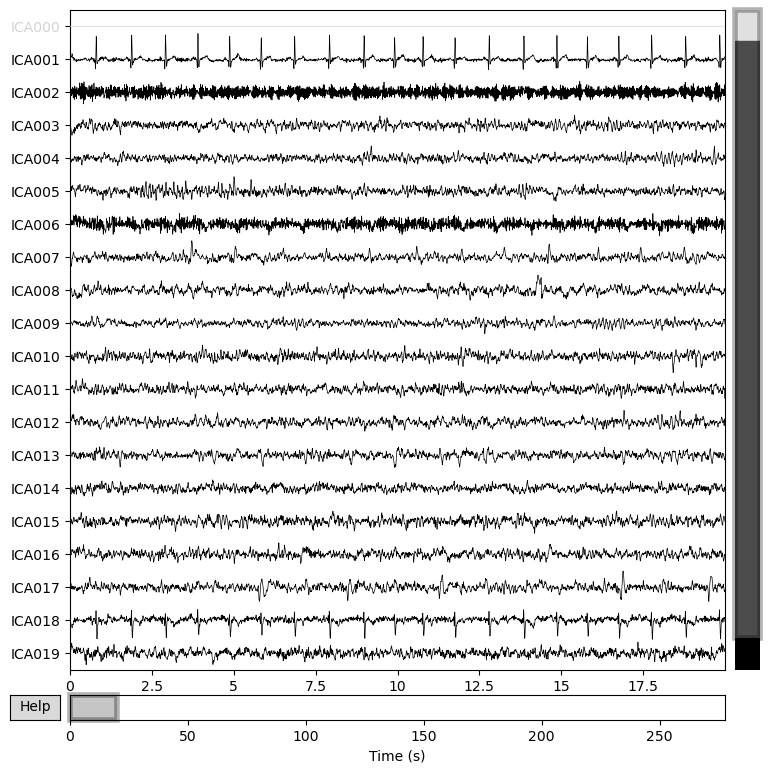

Creating RawArray with float64 data, n_channels=11, n_times=166800
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


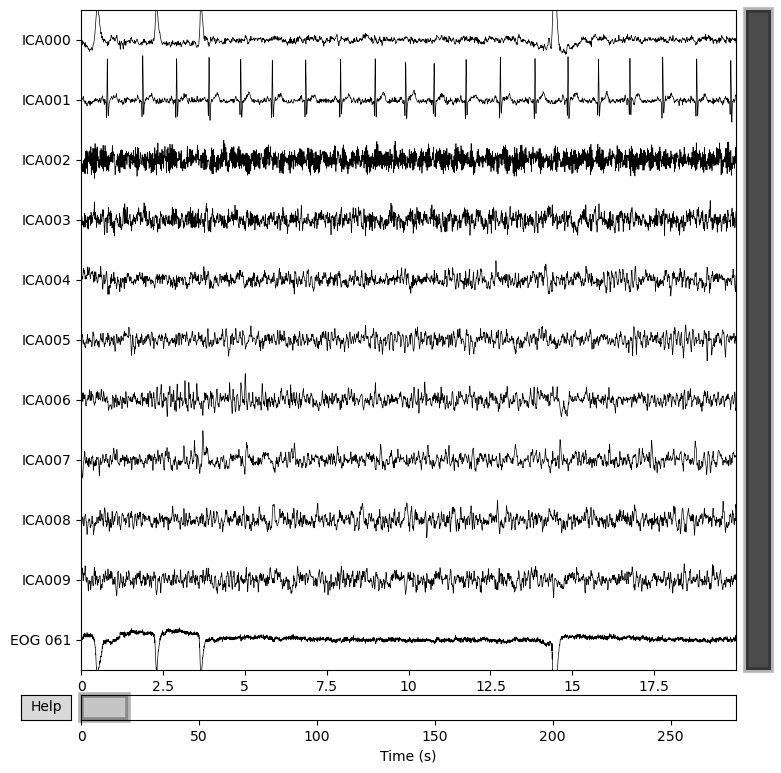

Creating RawArray with float64 data, n_channels=31, n_times=166800
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


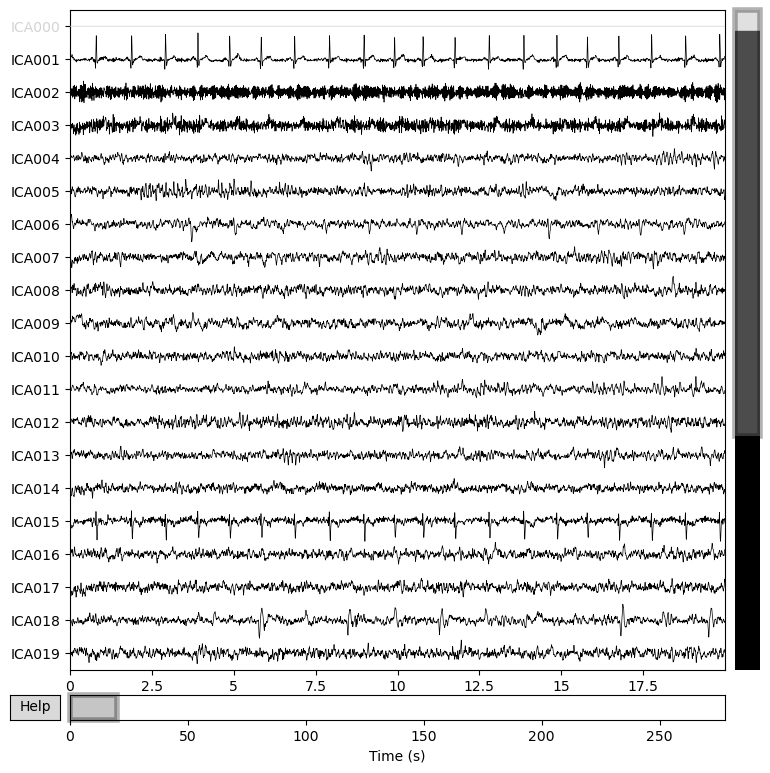

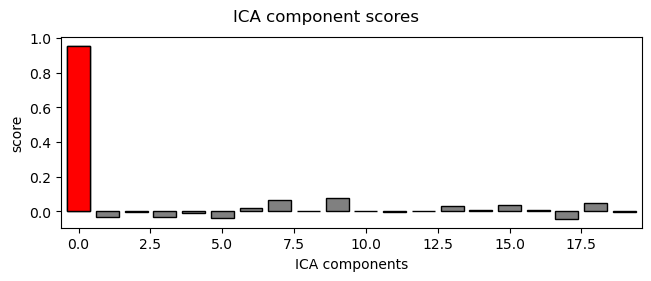

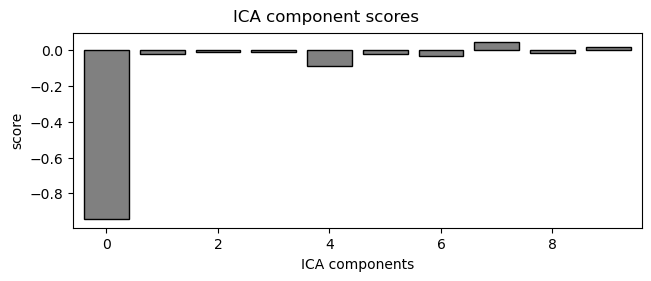

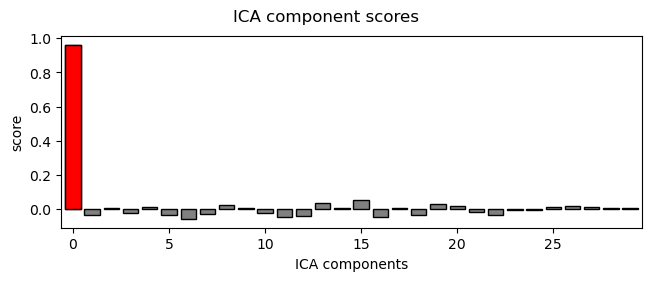

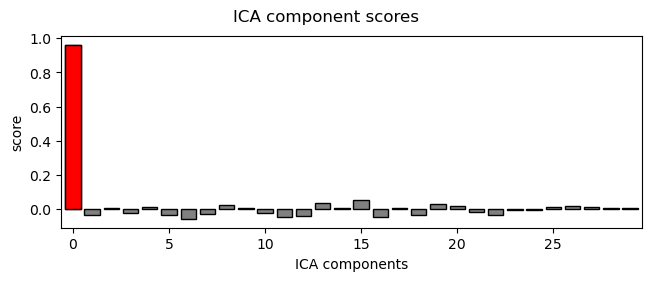

In [7]:
"""
1. `ica.plot_sources(raw)`로 시간축 성분을 그려 눈깜빡임의 큰 점프 위치 직접 찾기.
2. 자동 검출 결과와 본인이 눈으로 고른 인덱스 비교.
3. ICA 전/후 raw 데이터를 같은 구간에서 그려 잡음이 줄었는지 확인.
4. `n_components`를 10, 30으로 바꾸면 결과가 어떻게 달라지는지 실험.
"""

ica.exclude = [0]
raw_clean2 = ica.apply(raw.copy())

raw.plot(duration=10, start=10, title='No ICA')
raw_clean.plot(duration=10, start=10, title='Ai ICA')
raw_clean2.plot(duration=10, start=10, title='My ICA')

ica10 = mne.preprocessing.ICA(n_components=10, random_state=42)
ica30 = mne.preprocessing.ICA(n_components=30, random_state=42)

ica10.fit(raw)
ica10.plot_components()

ica30.fit(raw)
ica30.plot_components()

eog_indices10, eog_scores10 = ica10.find_bads_eog(raw)
print("EOG components 10:", eog_indices10)

eog_indices30, eog_scores30 = ica30.find_bads_eog(raw)
print("EOG components 30:", eog_indices30)

ica10.exclude = eog_indices10
raw_clean10 = ica10.apply(raw.copy())

ica30.exclude = eog_indices30
raw_clean30 = ica30.apply(raw.copy())

raw.plot(duration=10, start=10, title='Before ICA')
raw_clean10.plot(duration=10, start=10, title='After ICA10')
raw_clean30.plot(duration=10, start=10, title='After ICA30')
raw_clean.plot(duration=10, start=10, title='After ICA20')

ica.plot_sources(raw_clean, title='After 20: IC0 should be ~0')
ica10.plot_sources(raw_clean10, title='After 10: IC0 should be ~0')
ica30.plot_sources(raw_clean30, title='After 30: IC0 should be ~0')

ica.plot_scores(eog_scores)
ica10.plot_scores(eog_scores10)
ica30.plot_scores(eog_scores30)